# PodcastFillers Filler Word Detection for Interview Speech Fluency

Notebook ini membuat model deep learning TensorFlow untuk mendeteksi **filler word** pada audio, terinspirasi dari paper/jurnal Filler Word Detection and Classification.

Fokus notebook:
- Dataset: PodcastFillers
- Input: audio clip 1 detik `.wav`
- Output: `filler` vs `non_filler`
- Filler: `Uh`, `Um`
- Non-filler: `Words`, `Breath`, `Music`, `Laughter`, dan label lain non-filler
- Fitur audio: Log-Mel Spectrogram
- Model: CNN + BiLSTM classifier
- Training: custom training loop `tf.GradientTape`
- Checklist: TensorFlow model, custom loss, custom metric, TensorBoard, save model, evaluation, inference

Struktur folder yang diasumsikan saat VS Code dibuka di folder project:

```text
C:\KULIAH\Andro sems 6\Capstone\Filter Word Detection
├── PodcastFillers.csv
└── extracted
    └── PodcastFillers
        └── audio
            └── clip_wav
                ├── train
                ├── validation
                ├── test
                └── extra
```


In [1]:
# =========================
# OPTIONAL INSTALLS
# =========================
# Jalankan hanya jika package belum tersedia.
# Di VS Code, buka terminal di folder project lalu bisa install:
# pip install tensorflow pandas numpy scikit-learn matplotlib seaborn

# Jika dari notebook ingin install langsung, uncomment:
# !pip install tensorflow pandas numpy scikit-learn matplotlib seaborn


In [2]:
# =========================
# IMPORTS & CONFIG
# =========================

import os
import time
import json
import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support
)

print("TensorFlow:", tf.__version__)

# Matikan XLA untuk menghindari beberapa error graph optimizer di Windows/Kaggle.
tf.config.optimizer.set_jit(False)

# GPU memory growth agar tidak langsung mengambil semua VRAM.
gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as e:
        print("Could not set memory growth:", e)

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


TensorFlow: 2.21.0
GPUs: []


In [3]:
# =========================
# PATH DATASET
# =========================
# Karena VS Code dibuka di folder:
# C:\KULIAH\Andro sems 6\Capstone\Filter Word Detection
# maka Path.cwd() akan menunjuk ke folder itu.

PROJECT_DIR = Path.cwd()

CSV_PATH = PROJECT_DIR / "PodcastFillers.csv"
AUDIO_ROOT = PROJECT_DIR / "extracted" / "PodcastFillers" / "audio" / "clip_wav"

print("PROJECT_DIR:", PROJECT_DIR)
print("CSV exists       :", CSV_PATH.exists(), CSV_PATH)
print("AUDIO_ROOT exists:", AUDIO_ROOT.exists(), AUDIO_ROOT)

if not CSV_PATH.exists():
    raise FileNotFoundError(f"CSV tidak ditemukan: {CSV_PATH}")

if not AUDIO_ROOT.exists():
    raise FileNotFoundError(f"Folder audio tidak ditemukan: {AUDIO_ROOT}")


PROJECT_DIR: c:\KULIAH\Andro sems 6\Capstone\Filter Word Detection
CSV exists       : True c:\KULIAH\Andro sems 6\Capstone\Filter Word Detection\PodcastFillers.csv
AUDIO_ROOT exists: True c:\KULIAH\Andro sems 6\Capstone\Filter Word Detection\extracted\PodcastFillers\audio\clip_wav


In [4]:
# =========================
# LOAD CSV & BASIC CHECK
# =========================

df_raw = pd.read_csv(CSV_PATH)

print("CSV shape:", df_raw.shape)
print("Columns:")
print(df_raw.columns.tolist())

display(df_raw.head())

print("\nclip_split_subset distribution:")
print(df_raw["clip_split_subset"].value_counts(dropna=False))

print("\nlabel_consolidated_vocab distribution:")
print(df_raw["label_consolidated_vocab"].value_counts(dropna=False))


CSV shape: (85803, 17)
Columns:
['clip_name', 'pfID', 'label_full_vocab', 'label_consolidated_vocab', 'podcast_filename', 'event_start_inepisode', 'event_end_inepisode', 'event_start_inclip', 'event_end_inclip', 'clip_start_inepisode', 'clip_end_inepisode', 'duration', 'confidence', 'n_annotators', 'episode_split_subset', 'clip_split_subset', 'pitch_cent']


,clip_name,pfID,label_full_vocab,label_consolidated_vocab,podcast_filename,event_start_inepisode,event_end_inepisode,event_start_inclip,event_end_inclip,clip_start_inepisode,clip_end_inepisode,duration,confidence,n_annotators,episode_split_subset,clip_split_subset,pitch_cent
0,00000.wav,0,Agree,NaN,The Voice of 5G_Episode 12_5G & IoT,1592.770048,1593.129984,0.320032,0.679968,1592.450016,1593.450016,0.359936,1.0,2,train,extra,2335.659222
1,00001.wav,1,Music,Music,UX Podcast_#198 Connected content with Carrie ...,2231.030000,2231.420000,0.305000,0.695000,2230.725000,2231.725000,0.390000,1.0,2,train,train,1466.040477
2,00002.wav,2,Uh,Uh,Education_Ep 1 - Handmade Dev Show 2017,1271.340000,1271.790080,0.274960,0.725040,1271.065040,1272.065040,0.450080,1.0,2,validation,validation,1249.172108
3,00003.wav,3,Breath,Breath,Design Story_025 Moira Cullen Design is Soft P...,2608.590029,2608.770000,0.410014,0.589986,2608.180014,2609.180014,0.179971,1.0,2,test,test,6181.648929
4,00004.wav,4,Music,Music,The Come Up Show_Lizzo shares stories about he...,1139.150029,1139.410000,0.370014,0.629986,1138.780014,1139.780014,0.259971,1.0,3,train,train,3465.520202



clip_split_subset distribution:
clip_split_subset
train         64835
test           9475
extra          9114
validation     2379
Name: count, dtype: int64

label_consolidated_vocab distribution:
label_consolidated_vocab
Words       21733
Uh          17907
Um          17078
NaN          9114
Breath       8288
Laughter     6623
Music        5060
Name: count, dtype: int64


In [5]:
# =========================
# PREPARE DATAFRAME
# =========================
# Mengikuti split resmi dari dataset:
# train       -> training
# validation  -> validasi
# test        -> evaluasi akhir
#
# Optional:
# extra dapat ditambahkan ke train untuk memaksimalkan data training,
# tetapi tidak dicampur ke validation/test.

USE_EXTRA_FOR_TRAINING = True

VALID_SPLITS = ["train", "validation", "test"]
if USE_EXTRA_FOR_TRAINING:
    VALID_SPLITS.append("extra")

df = df_raw.copy()

# Gunakan hanya baris yang punya label consolidated.
df = df.dropna(subset=["label_consolidated_vocab"]).copy()

# Gunakan split resmi.
df = df[df["clip_split_subset"].isin(VALID_SPLITS)].copy()

# Buat path audio.
df["audio_path"] = df.apply(
    lambda row: AUDIO_ROOT / str(row["clip_split_subset"]) / str(row["clip_name"]),
    axis=1
)

df["audio_exists"] = df["audio_path"].apply(lambda p: p.exists())

print("Rows after filtering:", df.shape)
print("Audio exists :", int(df["audio_exists"].sum()))
print("Audio missing:", int((~df["audio_exists"]).sum()))

df = df[df["audio_exists"]].copy()

# Binary label:
# Uh/Um = filler
# selain itu = non_filler
FILLER_LABELS = ["Uh", "Um"]

df["label_binary"] = df["label_consolidated_vocab"].apply(
    lambda x: "filler" if x in FILLER_LABELS else "non_filler"
)

df["label_id"] = df["label_binary"].map({
    "non_filler": 0,
    "filler": 1
}).astype("int32")

# Official split
train_df = df[df["clip_split_subset"] == "train"].copy()
val_df = df[df["clip_split_subset"] == "validation"].copy()
test_df = df[df["clip_split_subset"] == "test"].copy()

# Optional: add extra to train only
if USE_EXTRA_FOR_TRAINING:
    extra_df = df[df["clip_split_subset"] == "extra"].copy()
    train_df = pd.concat([train_df, extra_df], ignore_index=True)

# Shuffle train
train_df = train_df.sample(frac=1.0, random_state=SEED).reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("\n=========================")
print("FINAL DATASET SUMMARY")
print("=========================")
print("Train:", train_df.shape)
print("Val  :", val_df.shape)
print("Test :", test_df.shape)

print("\nTrain label distribution:")
print(train_df["label_binary"].value_counts())

print("\nValidation label distribution:")
print(val_df["label_binary"].value_counts())

print("\nTest label distribution:")
print(test_df["label_binary"].value_counts())

print("\nConsolidated labels used:")
print(df["label_consolidated_vocab"].value_counts())

display(train_df[[
    "clip_name",
    "label_full_vocab",
    "label_consolidated_vocab",
    "label_binary",
    "label_id",
    "clip_split_subset",
    "audio_path"
]].head(20))


Rows after filtering: (76689, 19)
Audio exists : 76689
Audio missing: 0

FINAL DATASET SUMMARY
Train: (64835, 21)
Val  : (2379, 21)
Test : (9475, 21)

Train label distribution:
label_binary
non_filler    36042
filler        28793
Name: count, dtype: int64

Validation label distribution:
label_binary
non_filler    1231
filler        1148
Name: count, dtype: int64

Test label distribution:
label_binary
filler        5044
non_filler    4431
Name: count, dtype: int64

Consolidated labels used:
label_consolidated_vocab
Words       21733
Uh          17907
Um          17078
Breath       8288
Laughter     6623
Music        5060
Name: count, dtype: int64


,clip_name,label_full_vocab,label_consolidated_vocab,label_binary,label_id,clip_split_subset,audio_path
0,67725.wav,Uh,Uh,filler,1,train,c:\KULIAH\Andro sems 6\Capstone\Filter Word De...
1,44213.wav,Repetitions,Words,non_filler,0,train,c:\KULIAH\Andro sems 6\Capstone\Filter Word De...
2,16918.wav,Laughter,Laughter,non_filler,0,train,c:\KULIAH\Andro sems 6\Capstone\Filter Word De...
3,38473.wav,Uh,Uh,filler,1,train,c:\KULIAH\Andro sems 6\Capstone\Filter Word De...
4,64826.wav,Uh,Uh,filler,1,train,c:\KULIAH\Andro sems 6\Capstone\Filter Word De...
5,12666.wav,Um,Um,filler,1,train,c:\KULIAH\Andro sems 6\Capstone\Filter Word De...
6,36740.wav,Words,Words,non_filler,0,train,c:\KULIAH\Andro sems 6\Capstone\Filter Word De...
7,14207.wav,Um,Um,filler,1,train,c:\KULIAH\Andro sems 6\Capstone\Filter Word De...
8,77701.wav,Words,Words,non_filler,0,train,c:\KULIAH\Andro sems 6\Capstone\Filter Word De...
9,33674.wav,Music,Music,non_filler,0,train,c:\KULIAH\Andro sems 6\Capstone\Filter Word De...


In [6]:
# =========================
# CLASS WEIGHT
# =========================
# Dataset biasanya tidak seimbang:
# non_filler jauh lebih banyak daripada filler.
# Class weight membantu model tidak hanya menebak non_filler terus.

classes = np.array([0, 1], dtype=np.int32)

class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label_id"].values
)

CLASS_WEIGHT = {
    int(cls): float(weight)
    for cls, weight in zip(classes, class_weights_values)
}

print("CLASS_WEIGHT:", CLASS_WEIGHT)


CLASS_WEIGHT: {0: 0.8994367682148604, 1: 1.1258812905914632}


In [7]:
# =========================
# AUDIO CONFIG
# =========================

SAMPLE_RATE = 16000
CLIP_SECONDS = 1.0
TARGET_SAMPLES = int(SAMPLE_RATE * CLIP_SECONDS)

FRAME_LENGTH = 400      # 25 ms at 16 kHz
FRAME_STEP = 160        # 10 ms at 16 kHz
FFT_LENGTH = 512
NUM_MELS = 64
LOWER_EDGE_HZ = 80.0
UPPER_EDGE_HZ = 7600.0

NUM_SPECTROGRAM_BINS = FFT_LENGTH // 2 + 1

with tf.device("/CPU:0"):
    MEL_WEIGHT_MATRIX = tf.signal.linear_to_mel_weight_matrix(
        num_mel_bins=NUM_MELS,
        num_spectrogram_bins=NUM_SPECTROGRAM_BINS,
        sample_rate=SAMPLE_RATE,
        lower_edge_hertz=LOWER_EDGE_HZ,
        upper_edge_hertz=UPPER_EDGE_HZ
    )

print("TARGET_SAMPLES:", TARGET_SAMPLES)
print("NUM_MELS:", NUM_MELS)
print("MEL_WEIGHT_MATRIX:", MEL_WEIGHT_MATRIX.shape)


TARGET_SAMPLES: 16000
NUM_MELS: 64
MEL_WEIGHT_MATRIX: (257, 64)


In [8]:
# =========================
# CEK SAMPLE RATE AUDIO
# =========================
# Jika sample rate bukan 16000, notebook ini akan memberi error.
# PodcastFillers clip biasanya sudah siap sebagai clip audio pendek.

sample_audio_path = str(train_df.iloc[0]["audio_path"])

audio_bytes = tf.io.read_file(sample_audio_path)
audio, sr = tf.audio.decode_wav(audio_bytes, desired_channels=1)

print("Sample audio:", sample_audio_path)
print("Sample rate :", int(sr.numpy()))
print("Audio shape :", audio.shape)
print("Audio min/max:", float(tf.reduce_min(audio).numpy()), float(tf.reduce_max(audio).numpy()))

if int(sr.numpy()) != SAMPLE_RATE:
    raise ValueError(
        f"Sample rate audio = {int(sr.numpy())}, tetapi notebook memakai {SAMPLE_RATE}. "
        "Jika berbeda, tambahkan resampling atau ubah SAMPLE_RATE sesuai dataset."
    )


Sample audio: c:\KULIAH\Andro sems 6\Capstone\Filter Word Detection\extracted\PodcastFillers\audio\clip_wav\train\67725.wav
Sample rate : 16000
Audio shape : (16000, 1)
Audio min/max: -0.46478271484375 0.475006103515625


In [9]:
# =========================
# FEATURE EXTRACTION
# =========================

def load_wav_1sec(audio_path):
    audio_bytes = tf.io.read_file(audio_path)
    audio, sr = tf.audio.decode_wav(audio_bytes, desired_channels=1)
    audio = tf.squeeze(audio, axis=-1)

    # Validasi sample rate
    tf.debugging.assert_equal(
        sr,
        SAMPLE_RATE,
        message="Sample rate audio tidak sama dengan SAMPLE_RATE."
    )

    # Pad/truncate ke 1 detik agar shape konsisten.
    audio_len = tf.shape(audio)[0]

    audio = tf.cond(
        audio_len < TARGET_SAMPLES,
        lambda: tf.pad(audio, [[0, TARGET_SAMPLES - audio_len]]),
        lambda: audio[:TARGET_SAMPLES]
    )

    # Normalisasi aman.
    audio = tf.cast(audio, tf.float32)
    audio = audio / (tf.reduce_max(tf.abs(audio)) + 1e-6)

    return audio


def waveform_to_logmel(audio):
    stft = tf.signal.stft(
        audio,
        frame_length=FRAME_LENGTH,
        frame_step=FRAME_STEP,
        fft_length=FFT_LENGTH,
        pad_end=True
    )

    spectrogram = tf.abs(stft)
    power_spectrogram = tf.square(spectrogram)

    mel_spectrogram = tf.matmul(power_spectrogram, MEL_WEIGHT_MATRIX)
    log_mel = tf.math.log(mel_spectrogram + 1e-6)

    # Normalisasi per clip.
    mean = tf.reduce_mean(log_mel)
    std = tf.math.reduce_std(log_mel)
    log_mel = (log_mel - mean) / (std + 1e-6)

    # (time, mel, channel)
    log_mel = tf.expand_dims(log_mel, axis=-1)

    return log_mel


def preprocess_example(audio_path, label):
    audio = load_wav_1sec(audio_path)
    features = waveform_to_logmel(audio)
    label = tf.cast(label, tf.float32)
    return features, label


# Test satu sample
features, label = preprocess_example(
    tf.constant(str(train_df.iloc[0]["audio_path"])),
    tf.constant(int(train_df.iloc[0]["label_id"]))
)

print("Feature shape:", features.shape)
print("Label:", label.numpy())


Feature shape: (100, 64, 1)
Label: 1.0


In [10]:
# =========================
# TF.DATA PIPELINE
# =========================

BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

def make_dataset(dataframe, shuffle=False, batch_size=BATCH_SIZE, cache=False):
    audio_paths = dataframe["audio_path"].astype(str).values
    labels = dataframe["label_id"].astype("int32").values

    ds = tf.data.Dataset.from_tensor_slices((audio_paths, labels))

    if shuffle:
        ds = ds.shuffle(
            buffer_size=min(len(dataframe), 10000),
            seed=SEED,
            reshuffle_each_iteration=True
        )

    ds = ds.map(preprocess_example, num_parallel_calls=AUTOTUNE)

    if cache:
        # Hati-hati: cache ke RAM bisa besar.
        # Untuk 85k clip, lebih aman cache=False.
        ds = ds.cache()

    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)

    return ds


train_ds = make_dataset(train_df, shuffle=True, cache=False)
val_ds = make_dataset(val_df, shuffle=False, cache=False)
test_ds = make_dataset(test_df, shuffle=False, cache=False)

for xb, yb in train_ds.take(1):
    print("Batch X:", xb.shape)
    print("Batch y:", yb.shape)
    print("Labels :", yb[:10].numpy())


Batch X: (64, 100, 64, 1)
Batch y: (64,)
Labels : [1. 1. 1. 0. 1. 1. 1. 0. 0. 0.]


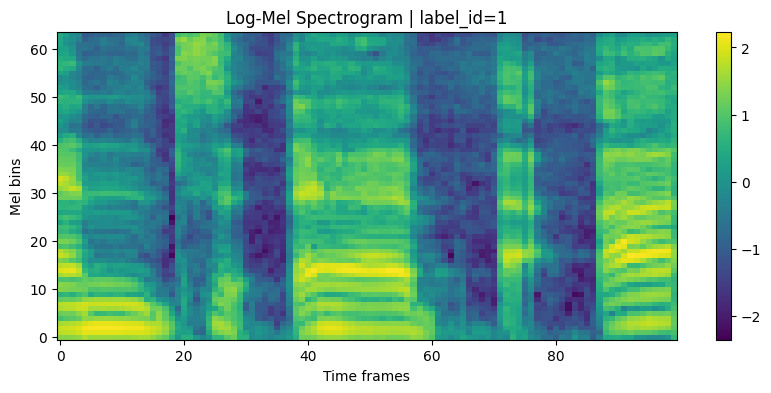

In [11]:
# =========================
# VISUALIZE LOG-MEL SAMPLE
# =========================

for xb, yb in train_ds.take(1):
    plt.figure(figsize=(10, 4))
    plt.imshow(tf.squeeze(xb[0], axis=-1).numpy().T, aspect="auto", origin="lower")
    plt.title(f"Log-Mel Spectrogram | label_id={int(yb[0].numpy())}")
    plt.xlabel("Time frames")
    plt.ylabel("Mel bins")
    plt.colorbar()
    plt.show()
    break


In [12]:
# =========================
# MODEL: CNN + BiLSTM
# =========================
# Model ini cocok untuk audio 1 detik:
# - CNN menangkap pola lokal pada spectrogram
# - BiLSTM membaca perubahan temporal
# - Output sigmoid untuk binary filler detection

def build_filler_detection_model(input_shape):
    inputs = layers.Input(shape=input_shape, name="logmel_input")

    x = layers.Conv2D(32, kernel_size=(3, 3), padding="same", use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.15)(x)

    x = layers.Conv2D(64, kernel_size=(3, 3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.20)(x)

    x = layers.Conv2D(128, kernel_size=(3, 3), padding="same", use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D(pool_size=(2, 2))(x)
    x = layers.Dropout(0.25)(x)

    # Convert 2D feature map to sequence.
    # Shape: (batch, time, freq, channel)
    # Gabungkan freq*channel sebagai feature per time-step.
    shape = tf.keras.backend.int_shape(x)
    time_steps = shape[1]
    freq_bins = shape[2]
    channels = shape[3]

    x = layers.Reshape((time_steps, freq_bins * channels), name="cnn_to_sequence")(x)

    x = layers.Bidirectional(
        layers.LSTM(96, return_sequences=True, dropout=0.2),
        name="bilstm_1"
    )(x)

    x = layers.Bidirectional(
        layers.LSTM(64, return_sequences=False, dropout=0.2),
        name="bilstm_2"
    )(x)

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.35)(x)

    # Logit output. Sigmoid diterapkan di loss/prediction.
    outputs = layers.Dense(1, name="filler_logit")(x)

    return keras.Model(inputs, outputs, name="podcastfillers_cnn_bilstm_binary")


INPUT_SHAPE = tuple(features.shape)
model = build_filler_detection_model(INPUT_SHAPE)
model.summary()


Model: "podcastfillers_cnn_bilstm_binary"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ logmel_input (InputLayer)       │ (None, 100, 64, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 100, 64, 32)    │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 64, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 100, 64, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 50, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 25, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 16, 128)    │        73,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 25, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 25, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 8, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 12, 8, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cnn_to_sequence (Reshape)       │ (None, 12, 1024)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 12, 192)        │       860,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ filler_logit (Dense)            │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,102,497 (4.21 MB)

 Trainable params: 1,102,049 (4.20 MB)

 Non-trainable params: 448 (1.75 KB)

In [13]:
# =========================
# CUSTOM LOSS & METRICS
# =========================

class WeightedBinaryCrossEntropy(keras.losses.Loss):
    def __init__(self, class_weight, name="weighted_binary_crossentropy"):
        super().__init__(name=name)
        self.w0 = tf.constant(class_weight[0], dtype=tf.float32)
        self.w1 = tf.constant(class_weight[1], dtype=tf.float32)

    def call(self, y_true, logits):
        y_true = tf.cast(tf.reshape(y_true, (-1, 1)), tf.float32)
        logits = tf.cast(logits, tf.float32)

        bce = tf.nn.sigmoid_cross_entropy_with_logits(
            labels=y_true,
            logits=logits
        )

        weights = tf.where(tf.equal(y_true, 1.0), self.w1, self.w0)
        loss = bce * weights

        return tf.reduce_mean(loss)


class BinaryF1Score(keras.metrics.Metric):
    def __init__(self, threshold=0.5, name="f1_score", **kwargs):
        super().__init__(name=name, **kwargs)
        self.threshold = threshold
        self.tp = self.add_weight(name="tp", initializer="zeros")
        self.fp = self.add_weight(name="fp", initializer="zeros")
        self.fn = self.add_weight(name="fn", initializer="zeros")

    def update_state(self, y_true, logits, sample_weight=None):
        y_true = tf.cast(tf.reshape(y_true, (-1, 1)), tf.float32)
        probs = tf.sigmoid(logits)
        y_pred = tf.cast(probs >= self.threshold, tf.float32)

        tp = tf.reduce_sum(y_true * y_pred)
        fp = tf.reduce_sum((1.0 - y_true) * y_pred)
        fn = tf.reduce_sum(y_true * (1.0 - y_pred))

        self.tp.assign_add(tp)
        self.fp.assign_add(fp)
        self.fn.assign_add(fn)

    def result(self):
        precision = self.tp / (self.tp + self.fp + 1e-7)
        recall = self.tp / (self.tp + self.fn + 1e-7)
        f1 = 2.0 * precision * recall / (precision + recall + 1e-7)
        return f1

    def reset_state(self):
        self.tp.assign(0.0)
        self.fp.assign(0.0)
        self.fn.assign(0.0)


loss_fn = WeightedBinaryCrossEntropy(CLASS_WEIGHT)
train_loss_metric = keras.metrics.Mean(name="train_loss")
val_loss_metric = keras.metrics.Mean(name="val_loss")

train_acc_metric = keras.metrics.BinaryAccuracy(name="train_accuracy", threshold=0.5)
val_acc_metric = keras.metrics.BinaryAccuracy(name="val_accuracy", threshold=0.5)

train_f1_metric = BinaryF1Score(name="train_f1")
val_f1_metric = BinaryF1Score(name="val_f1")

print("Custom loss and metrics ready.")


Custom loss and metrics ready.


In [14]:
# =========================
# TRAINING SETUP
# =========================

LEARNING_RATE = 1e-3
EPOCHS = 30
PATIENCE = 7

optimizer = keras.optimizers.Adam(
    learning_rate=LEARNING_RATE,
    clipnorm=1.0
)

RUN_ID = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")
LOG_DIR = Path("logs") / f"podcastfillers_binary_{RUN_ID}"
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = MODEL_DIR / "best_podcastfillers_filler_detector.keras"
LAST_MODEL_PATH = MODEL_DIR / "last_podcastfillers_filler_detector.keras"

summary_writer = tf.summary.create_file_writer(str(LOG_DIR))

print("LOG_DIR:", LOG_DIR)
print("BEST_MODEL_PATH:", BEST_MODEL_PATH)


LOG_DIR: logs\podcastfillers_binary_20260506-041826
BEST_MODEL_PATH: models\best_podcastfillers_filler_detector.keras


In [15]:
# =========================
# CUSTOM TRAINING STEP
# =========================

@tf.function(reduce_retracing=True)
def train_step(features, labels):
    with tf.GradientTape() as tape:
        logits = model(features, training=True)
        loss = loss_fn(labels, logits)

    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))

    probs = tf.sigmoid(logits)

    train_loss_metric.update_state(loss)
    train_acc_metric.update_state(labels, probs)
    train_f1_metric.update_state(labels, logits)

    return loss


@tf.function(reduce_retracing=True)
def val_step(features, labels):
    logits = model(features, training=False)
    loss = loss_fn(labels, logits)

    probs = tf.sigmoid(logits)

    val_loss_metric.update_state(loss)
    val_acc_metric.update_state(labels, probs)
    val_f1_metric.update_state(labels, logits)

    return loss


def reset_metrics():
    train_loss_metric.reset_state()
    val_loss_metric.reset_state()
    train_acc_metric.reset_state()
    val_acc_metric.reset_state()
    train_f1_metric.reset_state()
    val_f1_metric.reset_state()


def print_epoch_summary(epoch, epochs, train_loss, val_loss, train_acc, val_acc, train_f1, val_f1, elapsed):
    print(
        f"Epoch {epoch}/{epochs} - "
        f"{elapsed:.1f}s - "
        f"train_loss: {train_loss:.4f} - "
        f"val_loss: {val_loss:.4f} - "
        f"train_acc: {train_acc:.4f} - "
        f"val_acc: {val_acc:.4f} - "
        f"train_f1: {train_f1:.4f} - "
        f"val_f1: {val_f1:.4f}"
    )


In [16]:
# =========================
# TRAIN MODEL
# =========================

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_f1": [],
    "val_f1": []
}

best_val_f1 = -np.inf
wait = 0

train_batches = tf.data.experimental.cardinality(train_ds).numpy()
val_batches = tf.data.experimental.cardinality(val_ds).numpy()

print("Train batches:", train_batches)
print("Val batches  :", val_batches)

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()
    reset_metrics()

    print(f"\nEpoch {epoch}/{EPOCHS}")

    # Training
    for step, (features_batch, labels_batch) in enumerate(train_ds, start=1):
        loss = train_step(features_batch, labels_batch)

        if step % 100 == 0 or step == 1:
            print(
                f"  train step {step}/{train_batches} - "
                f"loss: {float(train_loss_metric.result().numpy()):.4f} - "
                f"acc: {float(train_acc_metric.result().numpy()):.4f} - "
                f"f1: {float(train_f1_metric.result().numpy()):.4f}",
                end="\r"
            )

    print()

    # Validation
    for features_batch, labels_batch in val_ds:
        val_step(features_batch, labels_batch)

    train_loss = float(train_loss_metric.result().numpy())
    val_loss = float(val_loss_metric.result().numpy())
    train_acc = float(train_acc_metric.result().numpy())
    val_acc = float(val_acc_metric.result().numpy())
    train_f1 = float(train_f1_metric.result().numpy())
    val_f1 = float(val_f1_metric.result().numpy())

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    elapsed = time.time() - start_time
    print_epoch_summary(
        epoch, EPOCHS,
        train_loss, val_loss,
        train_acc, val_acc,
        train_f1, val_f1,
        elapsed
    )

    with summary_writer.as_default():
        tf.summary.scalar("train_loss", train_loss, step=epoch)
        tf.summary.scalar("val_loss", val_loss, step=epoch)
        tf.summary.scalar("train_acc", train_acc, step=epoch)
        tf.summary.scalar("val_acc", val_acc, step=epoch)
        tf.summary.scalar("train_f1", train_f1, step=epoch)
        tf.summary.scalar("val_f1", val_f1, step=epoch)
        tf.summary.scalar("learning_rate", optimizer.learning_rate, step=epoch)

    # Save last model every epoch
    model.save(LAST_MODEL_PATH)

    # Save best by val_f1
    if val_f1 > best_val_f1:
        print(f"  val_f1 improved from {best_val_f1:.4f} to {val_f1:.4f}. Saving best model.")
        best_val_f1 = val_f1
        wait = 0
        model.save(BEST_MODEL_PATH)
    else:
        wait += 1
        print(f"  val_f1 did not improve. wait={wait}/{PATIENCE}")

    if wait >= PATIENCE:
        print(f"Early stopping at epoch {epoch}.")
        break

# Save history
history_path = MODEL_DIR / "training_history.json"
with open(history_path, "w", encoding="utf-8") as f:
    json.dump(history, f, indent=2)

print("\nTraining done.")
print("Best model:", BEST_MODEL_PATH)
print("Last model:", LAST_MODEL_PATH)
print("History:", history_path)


Train batches: 1014
Val batches  : 38

Epoch 1/30
  train step 1000/1014 - loss: 0.2774 - acc: 0.8880 - f1: 0.8737
Epoch 1/30 - 413.2s - train_loss: 0.2767 - val_loss: 0.2628 - train_acc: 0.8883 - val_acc: 0.8890 - train_f1: 0.8740 - val_f1: 0.8933
  val_f1 improved from -inf to 0.8933. Saving best model.

Epoch 2/30
  train step 1000/1014 - loss: 0.2159 - acc: 0.9203 - f1: 0.9097
Epoch 2/30 - 387.1s - train_loss: 0.2158 - val_loss: 0.1793 - train_acc: 0.9203 - val_acc: 0.9315 - train_f1: 0.9097 - val_f1: 0.9295
  val_f1 improved from 0.8933 to 0.9295. Saving best model.

Epoch 3/30
  train step 1000/1014 - loss: 0.2065 - acc: 0.9233 - f1: 0.9131
Epoch 3/30 - 373.0s - train_loss: 0.2062 - val_loss: 0.1650 - train_acc: 0.9234 - val_acc: 0.9424 - train_f1: 0.9132 - val_f1: 0.9397
  val_f1 improved from 0.9295 to 0.9397. Saving best model.

Epoch 4/30
  train step 1000/1014 - loss: 0.1978 - acc: 0.9274 - f1: 0.9177
Epoch 4/30 - 373.8s - train_loss: 0.1980 - val_loss: 0.1879 - train_acc: 0

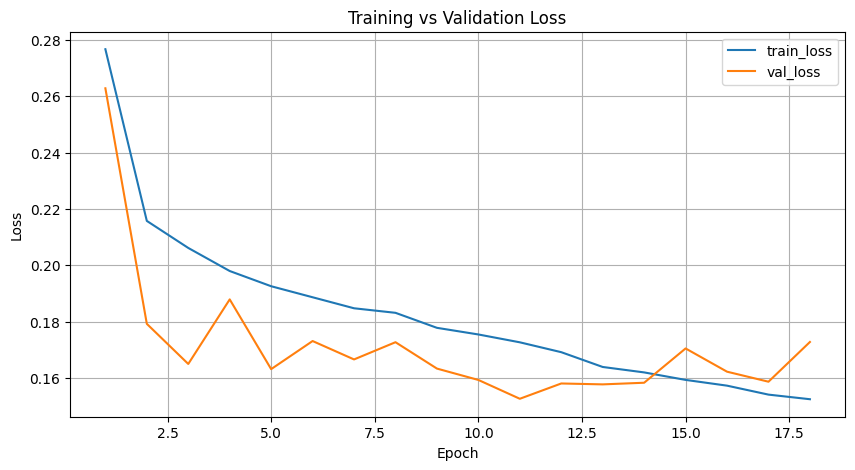

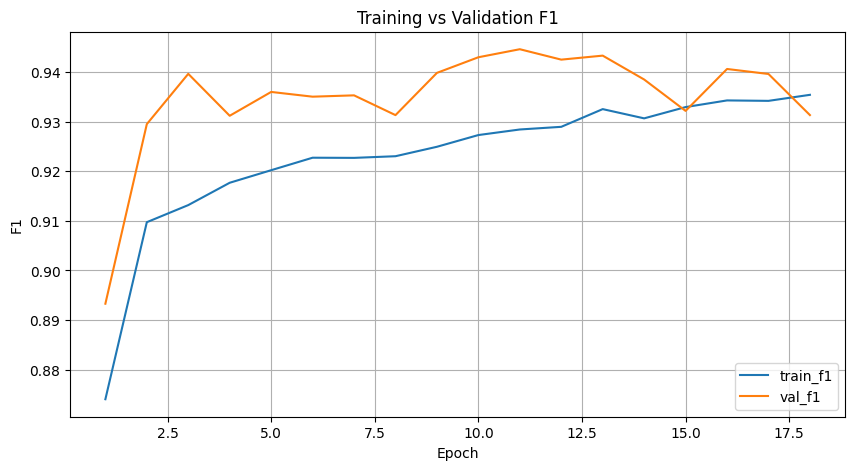

In [17]:
# =========================
# PLOT TRAINING HISTORY
# =========================

epochs_ran = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs_ran, history["train_loss"], label="train_loss")
plt.plot(epochs_ran, history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(epochs_ran, history["train_f1"], label="train_f1")
plt.plot(epochs_ran, history["val_f1"], label="val_f1")
plt.xlabel("Epoch")
plt.ylabel("F1")
plt.title("Training vs Validation F1")
plt.legend()
plt.grid(True)
plt.show()


In [18]:
# =========================
# LOAD BEST MODEL FOR EVALUATION
# =========================

best_model = keras.models.load_model(
    BEST_MODEL_PATH,
    custom_objects={
        "WeightedBinaryCrossEntropy": WeightedBinaryCrossEntropy,
        "BinaryF1Score": BinaryF1Score
    },
    compile=False
)

print("Loaded best model:", BEST_MODEL_PATH)


Loaded best model: models\best_podcastfillers_filler_detector.keras


TEST RESULTS
Accuracy : 0.9374142480211082
Precision: 0.9430619151901254
Recall   : 0.9391356066613799
F1       : 0.941094665739545

Classification report:
              precision    recall  f1-score   support

  non_filler       0.93      0.94      0.93      4431
      filler       0.94      0.94      0.94      5044

    accuracy                           0.94      9475
   macro avg       0.94      0.94      0.94      9475
weighted avg       0.94      0.94      0.94      9475

Confusion matrix:
[[4145  286]
 [ 307 4737]]


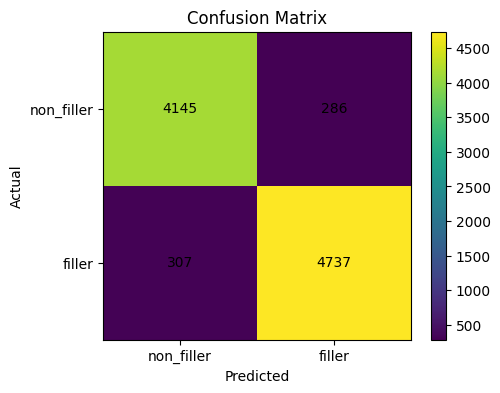

In [19]:
# =========================
# EVALUATION ON TEST SET
# =========================

def predict_dataset(model, dataset):
    all_probs = []
    all_true = []

    for features_batch, labels_batch in dataset:
        logits = model(features_batch, training=False)
        probs = tf.sigmoid(logits)
        all_probs.extend(probs.numpy().reshape(-1).tolist())
        all_true.extend(labels_batch.numpy().reshape(-1).astype(int).tolist())

    all_probs = np.array(all_probs)
    all_true = np.array(all_true)
    all_pred = (all_probs >= 0.5).astype(int)

    return all_true, all_pred, all_probs


y_true, y_pred, y_prob = predict_dataset(best_model, test_ds)

acc = accuracy_score(y_true, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred,
    average="binary",
    zero_division=0
)

print("TEST RESULTS")
print("Accuracy :", acc)
print("Precision:", precision)
print("Recall   :", recall)
print("F1       :", f1)

print("\nClassification report:")
print(classification_report(
    y_true,
    y_pred,
    target_names=["non_filler", "filler"],
    zero_division=0
))

cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix:")
print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks([0, 1], ["non_filler", "filler"])
plt.yticks([0, 1], ["non_filler", "filler"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")

plt.colorbar()
plt.show()


In [20]:
# =========================
# THRESHOLD TUNING ON VALIDATION SET
# =========================
# Untuk aplikasi interview, threshold dapat disesuaikan:
# - threshold rendah  -> lebih sensitif menemukan filler, tapi false positive naik
# - threshold tinggi  -> lebih ketat, tapi bisa miss filler

val_true, val_pred_default, val_prob = predict_dataset(best_model, val_ds)

thresholds = np.linspace(0.1, 0.9, 17)
rows = []

for th in thresholds:
    pred = (val_prob >= th).astype(int)
    p, r, f1_val, _ = precision_recall_fscore_support(
        val_true,
        pred,
        average="binary",
        zero_division=0
    )
    rows.append({
        "threshold": th,
        "precision": p,
        "recall": r,
        "f1": f1_val
    })

threshold_df = pd.DataFrame(rows)
display(threshold_df)

best_row = threshold_df.sort_values("f1", ascending=False).iloc[0]
BEST_THRESHOLD = float(best_row["threshold"])

print("Best threshold by validation F1:", BEST_THRESHOLD)
print(best_row)


,threshold,precision,recall,f1
0,0.10,0.829740,0.972125,0.895307
1,0.15,0.875791,0.964286,0.917910
2,0.20,0.900164,0.958188,0.928270
3,0.25,0.912427,0.952962,0.932254
4,0.30,0.922816,0.947735,0.935110
5,0.35,0.932874,0.944251,0.938528
6,0.40,0.942509,0.942509,0.942509
7,0.45,0.948944,0.939024,0.943958
8,0.50,0.953014,0.936411,0.944640
9,0.55,0.957066,0.932056,0.944395


Best threshold by validation F1: 0.5
threshold    0.500000
precision    0.953014
recall       0.936411
f1           0.944640
Name: 8, dtype: float64


In [21]:
# =========================
# INFERENCE FUNCTION
# =========================

LABEL_NAMES = {
    0: "non_filler",
    1: "filler"
}

def predict_filler_audio(audio_path, model=best_model, threshold=0.5):
    audio_path = str(audio_path)

    features, _ = preprocess_example(
        tf.constant(audio_path),
        tf.constant(0)
    )

    features = tf.expand_dims(features, axis=0)

    logit = model(features, training=False)
    prob = float(tf.sigmoid(logit).numpy().reshape(-1)[0])

    pred_id = int(prob >= threshold)
    pred_label = LABEL_NAMES[pred_id]

    return {
        "audio_path": audio_path,
        "filler_probability": prob,
        "prediction_id": pred_id,
        "prediction_label": pred_label,
        "threshold": threshold
    }


# Test inference dengan beberapa sample dari test set
for i in range(5):
    row = test_df.iloc[i]
    result = predict_filler_audio(row["audio_path"], threshold=BEST_THRESHOLD)

    print("Actual:", row["label_binary"], "| Consolidated:", row["label_consolidated_vocab"])
    print("Pred  :", result["prediction_label"], "| Prob:", round(result["filler_probability"], 4))
    print("Audio :", result["audio_path"])
    print("-" * 80)


Actual: non_filler | Consolidated: Breath
Pred  : non_filler | Prob: 0.0004
Audio : c:\KULIAH\Andro sems 6\Capstone\Filter Word Detection\extracted\PodcastFillers\audio\clip_wav\test\00003.wav
--------------------------------------------------------------------------------
Actual: non_filler | Consolidated: Words
Pred  : non_filler | Prob: 0.0691
Audio : c:\KULIAH\Andro sems 6\Capstone\Filter Word Detection\extracted\PodcastFillers\audio\clip_wav\test\00012.wav
--------------------------------------------------------------------------------
Actual: non_filler | Consolidated: Breath
Pred  : non_filler | Prob: 0.0013
Audio : c:\KULIAH\Andro sems 6\Capstone\Filter Word Detection\extracted\PodcastFillers\audio\clip_wav\test\00018.wav
--------------------------------------------------------------------------------
Actual: filler | Consolidated: Um
Pred  : filler | Prob: 0.9992
Audio : c:\KULIAH\Andro sems 6\Capstone\Filter Word Detection\extracted\PodcastFillers\audio\clip_wav\test\00025.wa

In [22]:
# =========================
# SAVE FINAL ARTIFACTS
# =========================

# Simpan threshold terbaik dan label mapping untuk dipakai di aplikasi.
metadata = {
    "task": "PodcastFillers binary filler word detection",
    "labels": LABEL_NAMES,
    "filler_labels": FILLER_LABELS,
    "best_threshold": BEST_THRESHOLD,
    "sample_rate": SAMPLE_RATE,
    "clip_seconds": CLIP_SECONDS,
    "num_mels": NUM_MELS,
    "frame_length": FRAME_LENGTH,
    "frame_step": FRAME_STEP,
    "fft_length": FFT_LENGTH,
    "model_path": str(BEST_MODEL_PATH)
}

metadata_path = MODEL_DIR / "podcastfillers_filler_detector_metadata.json"

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print("Saved metadata:", metadata_path)

# Save final best model copy with clear name
final_model_path = MODEL_DIR / "podcastfillers_filler_detector_final.keras"
best_model.save(final_model_path)

print("Saved final model:", final_model_path)


Saved metadata: models\podcastfillers_filler_detector_metadata.json
Saved final model: models\podcastfillers_filler_detector_final.keras


In [23]:
# =========================
# HOW TO OPEN TENSORBOARD
# =========================
# Di terminal VS Code, jalankan:
# tensorboard --logdir logs
#
# Lalu buka URL yang muncul, biasanya:
# http://localhost:6006

print("TensorBoard log dir:", LOG_DIR)


TensorBoard log dir: logs\podcastfillers_binary_20260506-041826


## Catatan untuk laporan

Model ini dapat ditulis sebagai:

> Modul Speech-to-Text pada simulasi interview menggunakan Whisper pretrained untuk menghasilkan transcript. Model deep learning custom difokuskan pada speech delivery analysis, yaitu Filler Word Detection. Model dilatih menggunakan PodcastFillers dengan input audio clip 1 detik dan fitur Log-Mel Spectrogram. Model mengklasifikasikan audio menjadi filler dan non-filler sehingga sistem dapat menghitung filler rate dan memberikan feedback kelancaran berbicara saat interview.

Alur integrasi aplikasi:

```text
Audio jawaban interview
↓
Whisper → transcript jawaban
↓
Sliding window audio 1 detik
↓
Filler Detector → filler probability per window
↓
Hitung filler count / filler rate
↓
GenAI memberi feedback isi jawaban + delivery
```
